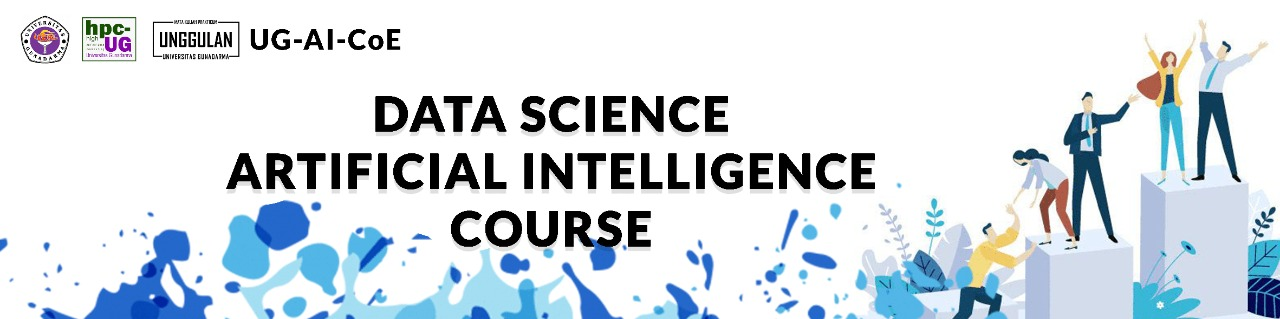

# Tugas Mandiri
---
Tugas mandiri ini digunakan pada kegiatan Kursus Data Science yang merupakan pembekalan bagi mahasiswa Universitas Gunadarma untuk Skema Supervisor Ilmuwan Data (Data Scientist Supervisor).

### Pertemuan 4 - Semester 7

## Implementasi Clustering untuk Menemukan Pola pada Data dengan Metodologi CRISP-DM


### Deskripsi Tugas
1. Mahasiswa harus membuat Project Data Science Sederhana dengan menggunakan algoritma clustering untuk menemukan kelompok atau pola tersembunyi pada suatu dataset.
2. Project dikerjakan secara lengkap mengikuti tahapan **CRISP-DM (Cross-Industry Standard Process for Data Mining)**, mulai dari Business Understanding hingga tahap Deployment.
3. Mahasiswa bebas memilih topik atau permasalahan yang relevan, selama project memiliki tujuan clustering yang jelas dan dataset memenuhi ketentuan yang telah ditetapkan.

### Ketentuan Dataset

Dataset yang digunakan harus memenuhi ketentuan berikut:
1. Berupa tabular dataset (.csv, .xlsx, atau sejenisnya).
2. Minimal 1000 baris dan 8 kolom.
3. Memiliki minimal 3 fitur numerik yang dapat digunakan untuk clustering.
4. Dataset memiliki karakteristik yang memungkinkan untuk dilakukan pengelompokan atau segmentasi.
5. Sumber dataset wajib dicantumkan dan berasal dari sumber yang jelas, seperti Kaggle, UCI, data.go.id, open data, atau dataset hasil pengumpulan sendiri.
6. Mahasiswa wajib menjelaskan secara singkat alasan dataset tersebut sesuai untuk permasalahan clustering.


<b>Catatan: Nilai akan dikurangi apabila dataset tidak memenuhi ketentuan.</b>

### Ketentuan Pengumpulan

Mahasiswa wajib mengumpulkan file berikut:
1. File Jupyter Notebook dengan format (`.ipynb`): Berisi seluruh proses CRISP-DM dari Business Understanding sampai Evaluation. **Notebook harus dapat dijalankan tanpa error.**

2. File Dataset: File dataset yang digunakan atau link sumber dataset.

3. Source Code Deployment
    <br> File yang digunakan untuk menjalankan aplikasi, misalnya: <br>
         

    *   app.py
    *   requirements.txt
    *   file konfigurasi atau file pendukung lainnya.


4. Link Deployment: Link aplikasi yang sudah dapat diakses melalui platform Streamlit.

<br>

<b>Seluruh file project dikumpulkan dalam satu folder Google Drive dengan akses *Anyone with the link → Editor*.</b> Tautan folder Google Drive kemudian dikumpulkan melalui Virtual Class sesuai dengan batas waktu yang telah ditentukan.

## 1. Business Understanding

**Permasalahan:** perilaku penggunaan kartu berbeda antar pelanggan. Pendekatan
layanan yang sama untuk semua pelanggan dapat mengabaikan variasi pembelian,
tarik tunai, dan pembayaran. Project ini menemukan kelompok pelanggan yang
perilakunya serupa untuk membantu analisis layanan dan komunikasi.

**Tujuan data mining:** membentuk segmen dari fitur perilaku tanpa label kelas,
menjelaskan profil setiap segmen pada satuan asli, dan menyediakan aplikasi
yang dapat menetapkan segmen pelanggan baru menggunakan pipeline yang sama.

**Pertanyaan analisis:** bagaimana pola pembelian dan tarik tunai berbeda antar
segmen? Berapa jumlah kelompok yang didukung metrik internal? Apakah hasil
cukup stabil terhadap inisialisasi dan masih menunjukkan pemisahan pada data
holdout yang tidak digunakan untuk memilih jumlah cluster?

**Kriteria keberhasilan project:** memenuhi ketentuan dataset, menjalankan
seluruh tahap CRISP-DM, memilih konfigurasi dengan alasan terukur, menghasilkan
profil kelompok yang dapat dijelaskan, serta membuat prediksi aplikasi sesuai
pipeline notebook. Silhouette, Davies–Bouldin, dan Calinski–Harabasz digunakan
untuk menilai struktur cluster. Tidak ditetapkan target akurasi karena tidak
tersedia label kelas acuan. Manfaat layanan merupakan hipotesis yang masih
memerlukan pengujian, bukan hasil peningkatan bisnis yang telah dibuktikan.

Segmen tidak dipakai untuk memutuskan pemberian kredit atau menyatakan fraud
maupun gagal bayar karena dataset tidak menyediakan label untuk tujuan itu.

## 2. Data Understanding

Deskripsi sumber data yaitu merangkum perilaku penggunaan sekitar 9.000 pemegang kartu
aktif selama enam bulan. File pengguna yang dianalisis berisi **8.950 baris dan
18 kolom**, dengan 17 fitur numerik dan satu identitas `CUST_ID`.

Setiap baris merepresentasikan pelanggan dan
berisi ukuran perilaku yang dapat dibandingkan. Kombinasi nominal, frekuensi,
transaksi, serta pembayaran memungkinkan pengelompokan berdasarkan kemiripan
tanpa memerlukan label target. `CUST_ID` dikeluarkan dari perhitungan jarak.
Nominal mengikuti satuan pada file; tidak diasumsikan sebagai rupiah.

In [ ]:
from pathlib import Path
import json
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
ROOT = Path.cwd()
if not (ROOT / 'modeling.py').exists() and (ROOT / 'cc_general_project/modeling.py').exists():
    ROOT = ROOT / 'cc_general_project'
sys.path.insert(0, str(ROOT))
from modeling import (
    FEATURES, LOG_FEATURES, DESCRIPTIONS, validate_features,
    make_preprocessor, select_model, fit_final_model, save_artifacts,
    predict_customers, dataset_sha256,
)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 22)

In [ ]:
DATA_PATH = ROOT / 'data/CC_GENERAL.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f'Ukuran dataset: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
print('SHA-256 dataset:', dataset_sha256(DATA_PATH))
display(df_raw.head())

Ukuran dataset: 8,950 baris × 18 kolom
SHA-256 dataset: 29eea6389837c40fd760c927b5782563edeff55a37824598489716bdb3563be1


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
numeric_count = df_raw.select_dtypes(include=np.number).shape[1]
requirements_check = pd.DataFrame({
    'Ketentuan': ['Dataset tabular', 'Minimal 1.000 baris', 'Minimal 8 kolom',
                 'Minimal 3 fitur numerik', 'Sumber dataset jelas'],
    'Hasil': ['CSV', str(len(df_raw)), str(df_raw.shape[1]), str(numeric_count), 'Kaggle — Arjun Bhasin'],
    'Terpenuhi': [True, len(df_raw) >= 1000, df_raw.shape[1] >= 8, numeric_count >= 3, True],
})
display(requirements_check)
assert requirements_check['Terpenuhi'].all()

,Ketentuan,Hasil,Terpenuhi
0,Dataset tabular,CSV,True
1,Minimal 1.000 baris,8950,True
2,Minimal 8 kolom,18,True
3,Minimal 3 fitur numerik,17,True
4,Sumber dataset jelas,Kaggle — Arjun Bhasin,True


In [ ]:
dictionary = pd.DataFrame({'Fitur': FEATURES,
                           'Arti ringkas': [DESCRIPTIONS[c] for c in FEATURES]})
display(dictionary)

,Fitur,Arti ringkas
0,BALANCE,Saldo pada akun kartu
1,BALANCE_FREQUENCY,Frekuensi pembaruan saldo (0–1)
2,PURCHASES,Nilai pembelian
3,ONEOFF_PURCHASES,Nilai pembelian sekali bayar
4,INSTALLMENTS_PURCHASES,Nilai pembelian cicilan
5,CASH_ADVANCE,Nilai tarik tunai
6,PURCHASES_FREQUENCY,Frekuensi pembelian (0–1)
7,ONEOFF_PURCHASES_FREQUENCY,Frekuensi pembelian sekali bayar (0–1)
8,PURCHASES_INSTALLMENTS_FREQUENCY,Frekuensi pembelian cicilan (0–1)
9,CASH_ADVANCE_FREQUENCY,"Frekuensi tarik tunai (maksimum teramati 1,5)"


In [ ]:
df_raw.info()
quality = pd.DataFrame({'Tipe': df_raw.dtypes.astype(str),
                        'Kosong': df_raw.isna().sum(),
                        'Persen kosong': df_raw.isna().mean() * 100})
display(quality.round(3))
print('Duplikasi baris:', df_raw.duplicated().sum())
print('CUST_ID unik:', df_raw['CUST_ID'].nunique())
print('CASH_ADVANCE_FREQUENCY > 1:', (df_raw['CASH_ADVANCE_FREQUENCY'] > 1).sum())
display(df_raw[FEATURES].describe().T.round(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,Tipe,Kosong,Persen kosong
CUST_ID,object,0,0.000
BALANCE,float64,0,0.000
BALANCE_FREQUENCY,float64,0,0.000
PURCHASES,float64,0,0.000
ONEOFF_PURCHASES,float64,0,0.000
INSTALLMENTS_PURCHASES,float64,0,0.000
CASH_ADVANCE,float64,0,0.000
PURCHASES_FREQUENCY,float64,0,0.000
ONEOFF_PURCHASES_FREQUENCY,float64,0,0.000
PURCHASES_INSTALLMENTS_FREQUENCY,float64,0,0.000


Duplikasi baris: 0
CUST_ID unik: 8950
CASH_ADVANCE_FREQUENCY > 1: 8


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.475,2081.532,0.000,128.282,873.385,2054.140,19043.139
BALANCE_FREQUENCY,8950.0,0.877,0.237,0.000,0.889,1.000,1.000,1.000
PURCHASES,8950.0,1003.205,2136.635,0.000,39.635,361.280,1110.130,49039.570
ONEOFF_PURCHASES,8950.0,592.437,1659.888,0.000,0.000,38.000,577.405,40761.250
INSTALLMENTS_PURCHASES,8950.0,411.068,904.338,0.000,0.000,89.000,468.638,22500.000
CASH_ADVANCE,8950.0,978.871,2097.164,0.000,0.000,0.000,1113.821,47137.212
PURCHASES_FREQUENCY,8950.0,0.490,0.401,0.000,0.083,0.500,0.917,1.000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202,0.298,0.000,0.000,0.083,0.300,1.000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364,0.397,0.000,0.000,0.167,0.750,1.000
CASH_ADVANCE_FREQUENCY,8950.0,0.135,0.200,0.000,0.000,0.000,0.222,1.500


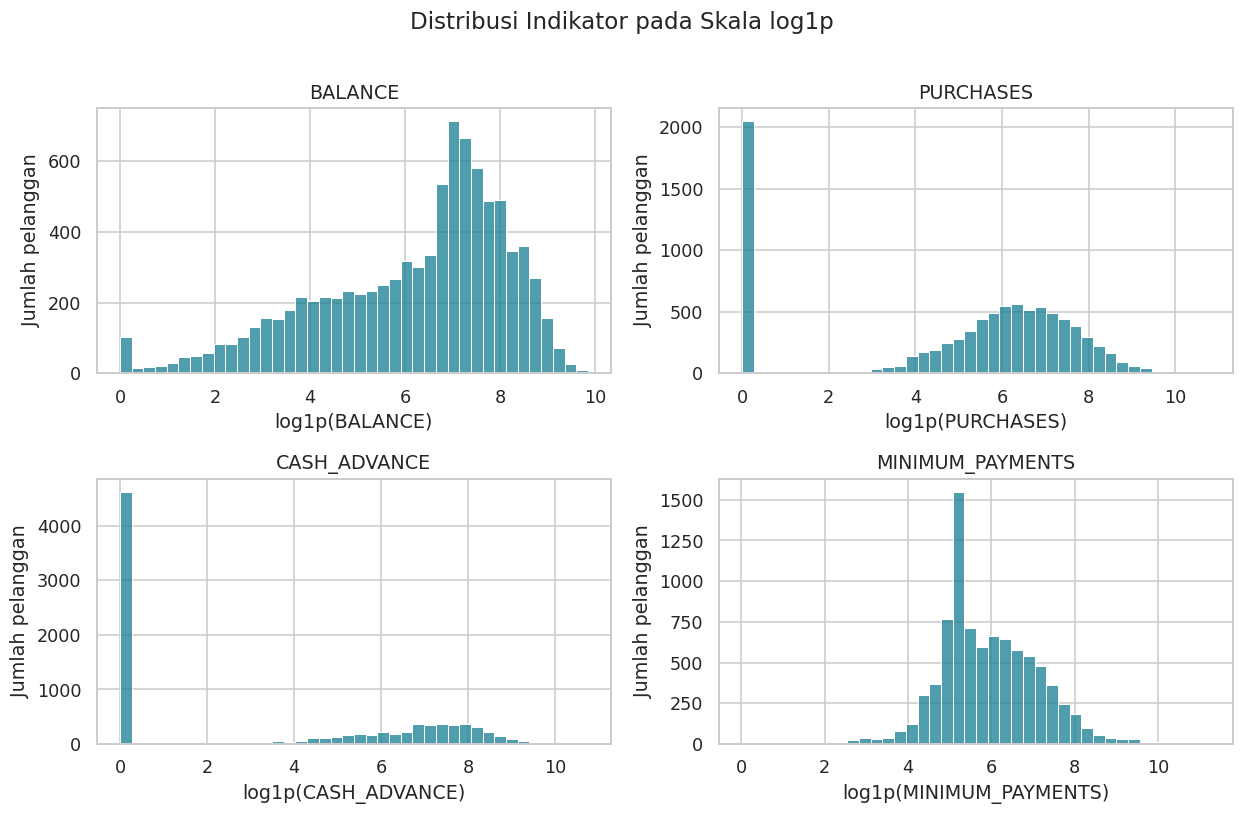

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, column in zip(axes.ravel(), ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'MINIMUM_PAYMENTS']):
    sns.histplot(np.log1p(df_raw[column].dropna()), bins=40, ax=ax, color='#147D92')
    ax.set(title=column, xlabel=f'log1p({column})', ylabel='Jumlah pelanggan')
fig.suptitle('Distribusi Indikator pada Skala log1p', y=1.01)
fig.tight_layout()
plt.show()

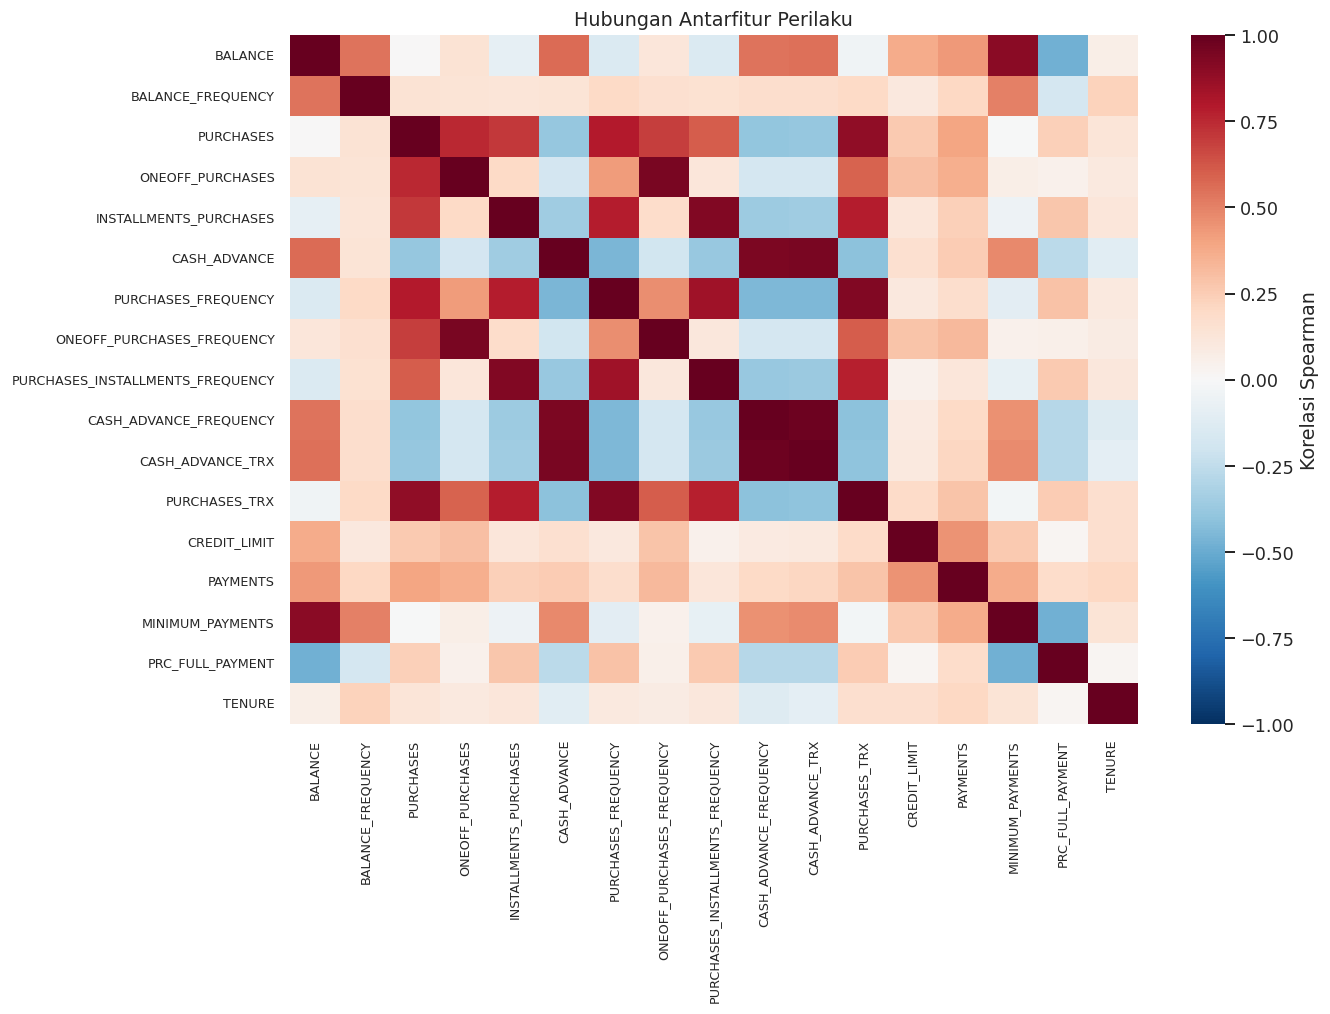

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_raw[FEATURES].corr(method='spearman'), cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Korelasi Spearman'})
ax.set_title('Hubungan Antarfitur Perilaku')
ax.tick_params(axis='both', labelsize=8)
fig.tight_layout()
plt.show()

## 3. Data Preparation

1. Pertahankan `CUST_ID` sebagai identitas, lalu gunakan 17 fitur numerik.
2. Periksa skema, nilai posiif, nilai negatif, dan nilai tak terhingga.
3. Bagi data menjadi **80% latih dan 20% holdout** dengan `random_state=42`.
4. Standardisasi fitur agar perbedaan satuan tidak mendominasi jarak Euclidean.


In [ ]:
df = df_raw.drop_duplicates().reset_index(drop=True)
X = validate_features(df)
print('Fitur:', FEATURES)
print('Fitur log1p:', LOG_FEATURES)
print('Ukuran matriks fitur:', X.shape)
display(make_preprocessor())

Fitur: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Fitur log1p: ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']
Ukuran matriks fitur: (8950, 17)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columns', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('other', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 4. Modeling

**K-Means** dipilih karena efisien pada data numerik dan memiliki `predict`
untuk menetapkan segmen pelanggan baru. Keterbatasannya adalah kecenderungan
membentuk cluster kompak, sensitif terhadap skala, serta tidak memberi label noise.

Kandidat **k = 2–8** diuji dengan `n_init=20` dan `random_state=42`.
Pemilihan menggunakan **silhouette tertinggi pada sampel tetap 2.500 data latih**.
Inertia (elbow), Davies–Bouldin, ukuran cluster, dan Calinski–Harabasz memberi
konteks tambahan. Holdout tidak dipakai untuk memilih k. Sampel silhouette
membatasi biaya perhitungan pasangan jarak; hasilnya merupakan estimasi,
bukan penghitungan silhouette seluruh data latih.


In [ ]:
selected = select_model(X)
comparison = selected['selection']
best_k = selected['best_k']
print(f"Latih: {len(selected['train'])}; holdout: {len(selected['test'])}")
display(comparison.round(5))
print(f'Jumlah cluster terpilih: {best_k}')

Latih: 7160; holdout: 1790


,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size
0,2,90404.39822,0.24725,1.49755,2479.49761,2521
1,3,76360.56845,0.21619,1.68139,2125.68999,2307
2,4,69152.87383,0.20991,1.69008,1813.23183,1322
3,5,62384.27260,0.21207,1.59994,1701.33878,1105
4,6,57354.92651,0.21619,1.46971,1605.67893,801
5,7,54314.77458,0.21887,1.41776,1479.49792,397
6,8,51637.12994,0.20908,1.46436,1386.69991,356


Jumlah cluster terpilih: 2


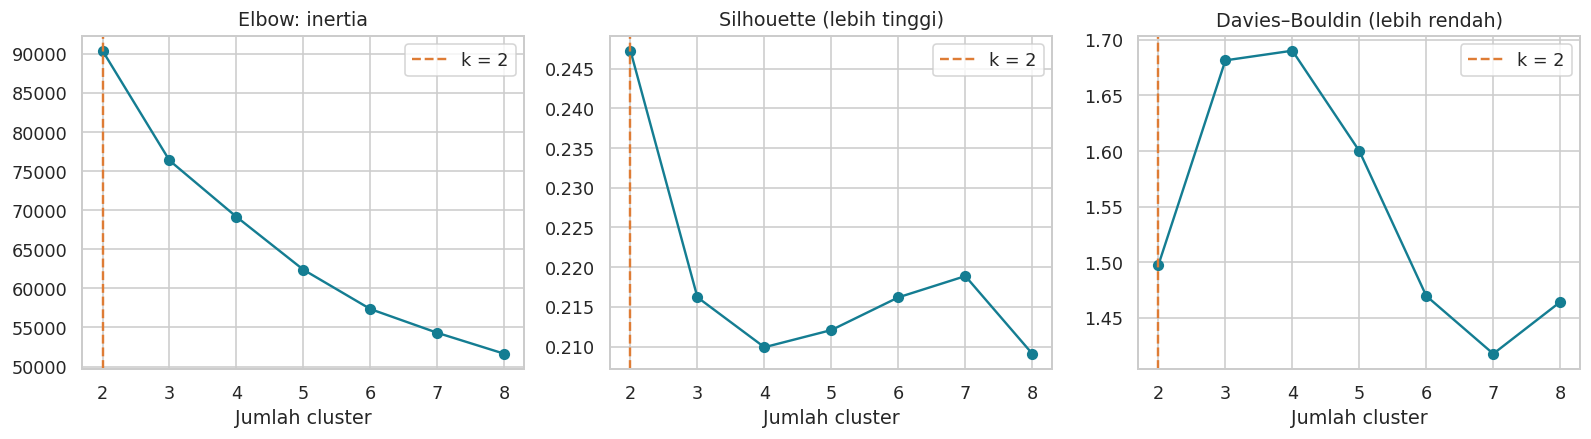

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, title in zip(axes, ['inertia', 'silhouette', 'davies_bouldin'],
                            ['Elbow: inertia', 'Silhouette (lebih tinggi)', 'Davies–Bouldin (lebih rendah)']):
    ax.plot(comparison.k, comparison[metric], 'o-', color='#147D92')
    ax.axvline(best_k, color='#DE7C35', linestyle='--', label=f'k = {best_k}')
    ax.set(title=title, xlabel='Jumlah cluster', xticks=comparison.k)
    ax.legend()
fig.tight_layout()
plt.show()

## 5. Evaluation

Model dengan k terpilih menetapkan label pada **1.790 pelanggan holdout**.
Silhouette holdout dihitung menggunakan seluruh data holdout, sedangkan
Davies–Bouldin dan Calinski–Harabasz menggambarkan penyebaran dan pemisahan
cluster. Tidak ada akurasi, precision, atau recall karena label acuan tidak ada.

Stabilitas inisialisasi diperiksa melalui Adjusted Rand Index (ARI) antara
hasil data latih dari seed 42 dan seed 7, 21, 99. ARI mendekati 1 berarti
keanggotaan konsisten meskipun nomor label dapat berubah. Pemeriksaan ini
hanya menguji sensitivitas inisialisasi, bukan stabilitas terhadap waktu atau
perubahan populasi pelanggan.

In [ ]:
holdout = selected['holdout']
display(pd.DataFrame([holdout], index=['Holdout 20%']).round(5))
display(pd.DataFrame(selected['stability']).round(5))

,silhouette,davies_bouldin,calinski_harabasz
Holdout 20%,0.24632,1.51346,595.00682


,seed,adjusted_rand_index
0,7,0.99944
1,21,0.99944
2,99,0.99944


Setelah evaluasi holdout selesai, model deployment dilatih ulang pada
seluruh 8.950 pelanggan dengan k yang sudah dipilih. **Metrik holdout di atas
berasal dari model data latih**, sedangkan profil berikut berasal dari model
final yang dilatih pada seluruh dataset. Nomor segmen diurutkan berdasarkan
rata-rata frekuensi pembelian agar mudah ditafsirkan; pengurutan ini tidak
mengubah anggota cluster.

In [ ]:
final = fit_final_model(df, selected)
bundle = final['bundle']
metadata = bundle['metadata']
display(final['profile'].round(3))
print('Median indikator utama:')
display(final['median_profile'][['PURCHASES', 'CASH_ADVANCE', 'BALANCE', 'PAYMENTS']].round(3))
print('Metrik model final (silhouette pada sampel 3.000 baris):')
display(pd.DataFrame([metadata['final_metrics_sample_3000']]).round(5))

,Jumlah,Persentase,Nama_Segmen,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Segment,,,,,,,,,,,,,,,,,,,,
S1,3163,35.341,Aktivitas belanja lebih rendah,2361.29,0.904,149.720,120.082,29.676,2156.576,0.096,0.055,0.040,0.293,7.131,1.707,4302.30,1781.294,1104.975,0.039,11.329
S2,5787,64.659,Aktivitas belanja lebih tinggi,1128.96,0.862,1469.694,850.612,619.525,335.173,0.706,0.283,0.542,0.049,1.127,21.817,4599.44,1706.826,732.235,0.217,11.620


Median indikator utama:


,PURCHASES,CASH_ADVANCE,BALANCE,PAYMENTS
Segment,,,,
S1,0.00,1319.277,1589.083,848.816
S2,731.45,0.000,379.198,860.545


Metrik model final (silhouette pada sampel 3.000 baris):


,silhouette,davies_bouldin,calinski_harabasz
0,0.24814,1.50631,3064.87428


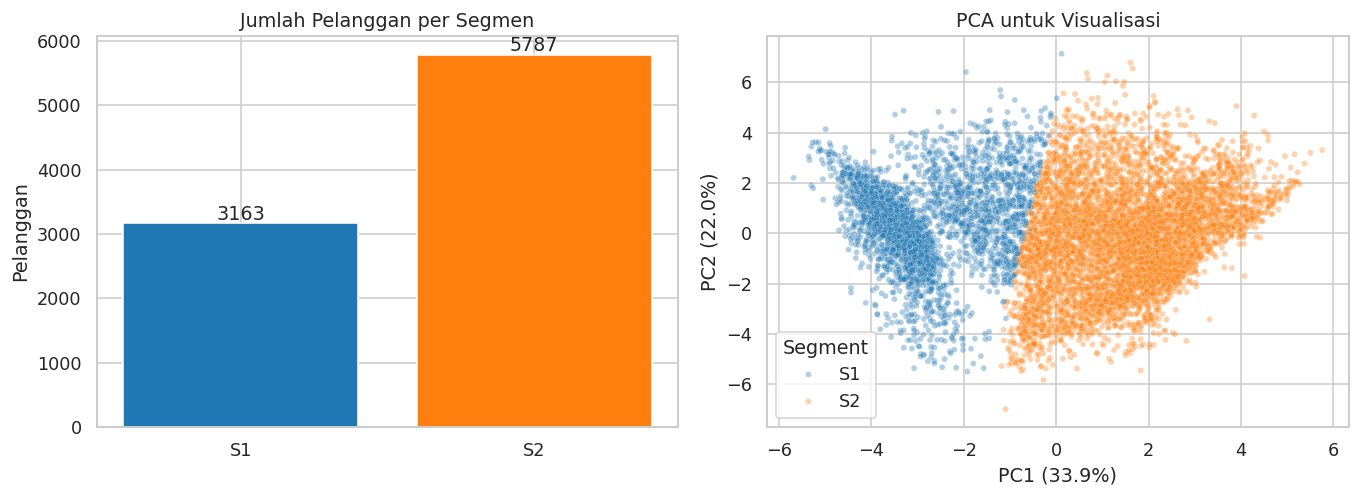

Dua komponen PCA merangkum 55.84% variasi data.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
counts = final['assignments']['Segment'].value_counts().sort_index()
colors = {segment: plt.get_cmap('tab10')(i) for i, segment in enumerate(counts.index)}
axes[0].bar(counts.index, counts.values, color=[colors[s] for s in counts.index])
for index, value in enumerate(counts.values):
    axes[0].text(index, value, str(value), ha='center', va='bottom')
axes[0].set(title='Jumlah Pelanggan per Segmen', ylabel='Pelanggan')
projection = final['projection']
sns.scatterplot(data=projection, x='PC1', y='PC2', hue='Segment',
                palette=colors, hue_order=list(counts.index), alpha=0.35, s=14, ax=axes[1])
variance = metadata['pca_explained_variance']
axes[1].set(title='PCA untuk Visualisasi', xlabel=f'PC1 ({variance[0]:.1%})',
            ylabel=f'PC2 ({variance[1]:.1%})')
fig.tight_layout()
plt.show()
print(f'Dua komponen PCA merangkum {sum(variance):.2%} variasi data.')

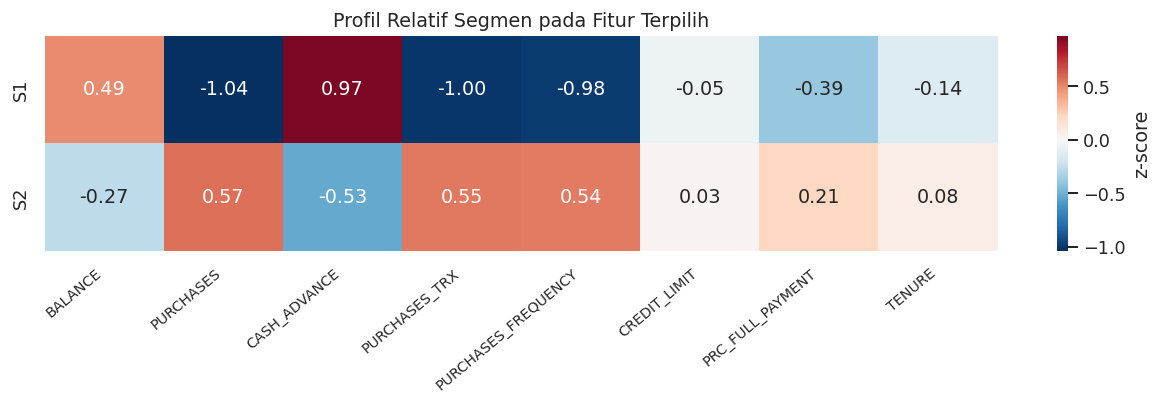

In [ ]:
display_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PURCHASES_TRX',
                    'PURCHASES_FREQUENCY', 'CREDIT_LIMIT', 'PRC_FULL_PAYMENT', 'TENURE']
fig, ax = plt.subplots(figsize=(11, 3.7))
sns.heatmap(final['standardized_profile'][display_features], annot=True,
            fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'z-score'})
ax.set_title('Profil Relatif Segmen pada Fitur Terpilih')
ax.tick_params(axis='x', labelrotation=40, labelsize=9)
plt.setp(ax.get_xticklabels(), ha='right')
fig.tight_layout()
plt.show()

In [ ]:
profile = final['profile']
lines = [f"**Hasil:** k = {best_k}; silhouette holdout = {holdout['silhouette']:.4f}. "
         "Pemisahan positif menunjukkan adanya struktur rata-rata, tetapi tumpang tindih "
         "tetap terlihat sehingga segmen perlu dipakai secara eksploratif."]
for segment, row in profile.iterrows():
    lines.append(f"- **{segment} — {row.Nama_Segmen}:** {int(row.Jumlah):,} pelanggan "
                 f"({row.Persentase:.2f}%). Rata-rata PURCHASES {row.PURCHASES:,.2f}, "
                 f"CASH_ADVANCE {row.CASH_ADVANCE:,.2f}, PURCHASES_FREQUENCY "
                 f"{row.PURCHASES_FREQUENCY:.3f}, dan PRC_FULL_PAYMENT {row.PRC_FULL_PAYMENT:.3f}.")
display(Markdown('\n\n'.join(lines)))

**Hasil:** k = 2; silhouette holdout = 0.2463. Pemisahan positif menunjukkan adanya struktur rata-rata, tetapi tumpang tindih tetap terlihat sehingga segmen perlu dipakai secara eksploratif.

- **S1 — Aktivitas belanja lebih rendah:** 3,163 pelanggan (35.34%). Rata-rata PURCHASES 149.72, CASH_ADVANCE 2,156.58, PURCHASES_FREQUENCY 0.096, dan PRC_FULL_PAYMENT 0.039.

- **S2 — Aktivitas belanja lebih tinggi:** 5,787 pelanggan (64.66%). Rata-rata PURCHASES 1,469.69, CASH_ADVANCE 335.17, PURCHASES_FREQUENCY 0.706, dan PRC_FULL_PAYMENT 0.217.

**Implikasi bisnis yang dapat diuji:** untuk kelompok dengan pembelian lebih
jarang, teliti kebutuhan dan hambatan penggunaan melalui survei serta komunikasi
fitur layanan. Untuk kelompok dengan pembelian lebih aktif, uji personalisasi
informasi transaksi dan program retensi. Pola tarik tunai dan pembayaran dibaca
bersama profil lengkap; intensitas transaksi tidak otomatis menunjukkan risiko.

**Keterbatasan:** kelompok mencerminkan snapshot dataset. Fitur yang berkorelasi
dapat memberi bobot lebih besar pada aspek perilaku yang sama. Pemilihan k
berbasis silhouette sampel tidak menjamin optimum seluruh populasi atau seluruh
algoritma. PCA merangkum sebagian variasi saja. Tidak tersedia hasil kampanye,
label gagal bayar, atau urutan waktu untuk membuktikan dampak bisnis maupun
menguji generalisasi temporal.

## 6. Deployment

Pipeline lengkap disimpan sebagai `artifacts/cc_general_pipeline.joblib`,
termasuk preprocessing, model, pemetaan nama segmen, dan PCA. Aplikasi memuat
artefak ini dan tidak melatih ulang model pada setiap interaksi.

**Fitur aplikasi:** ringkasan dan profil segmen; formulir 17 fitur untuk satu
pelanggan; upload CSV untuk banyak pelanggan; unduh hasil segmentasi; dan
penjelasan metode serta evaluasi. Validasi input memeriksa kolom, tipe,
nilai negatif, proporsi, dan jumlah transaksi. Nilai kosong diimputasi memakai
median yang dipelajari saat pelatihan, bukan median dari file prediksi.

In [ ]:
save_artifacts(ROOT, final, selected)
loaded = joblib.load(ROOT / 'artifacts/cc_general_pipeline.joblib')
test_prediction = predict_customers(loaded, df.head(20))
assert np.array_equal(test_prediction['Segment'].to_numpy(),
                      final['assignments'].head(20)['Segment'].to_numpy())
print('Model berhasil disimpan/dimuat ulang; 20 hasil prediksi tetap identik.')
display(test_prediction[['CUST_ID', 'Segment', 'Nama_Segmen', 'Jarak_Centroid']].head())

Model berhasil disimpan/dimuat ulang; 20 hasil prediksi tetap identik.


,CUST_ID,Segment,Nama_Segmen,Jarak_Centroid
0,C10001,S2,Aktivitas belanja lebih tinggi,3.537899
1,C10002,S1,Aktivitas belanja lebih rendah,2.126628
2,C10003,S2,Aktivitas belanja lebih tinggi,3.891254
3,C10004,S1,Aktivitas belanja lebih rendah,5.415926
4,C10005,S1,Aktivitas belanja lebih rendah,3.370516


**lokal:**

```bash
python -m pip install -r requirements.txt
python -m streamlit run app.py
```


---

Copyright © 2026 by Tim Pengembangan DGX, Universitas Gunadarma


https://www.hpc-hub.gunadarma.ac.id/